# analytical wind-driven currents Lilly & Elipot 2021

In [2]:
import numpy as np
import pandas as pd
import xarray as xr

from scipy.special import iv, kv, erf
from scipy.fft import fftfreq, fft, ifft

# import scipy as sc

import matplotlib.pyplot as plt

%matplotlib inline

---

## dev tests

In [3]:
rho = 1025  # kg/m^3
f = 2 * 2 * np.pi * np.sin(np.deg2rad(43)) / 86400
h = 50  # m

delta = 4  # m
z0 = 4  # m

# K0 = 1e-3 # m^2/s
K0 = delta**2 * f / 2
# K1 = 1e-3/100 # m/s
K1 = K0 / z0

# derived
# delta = np.sqrt(2*K0/f)
mu = 2 * K1 / f
# z0 = K0/K1

print(f"K0={K0:.2e} m2/s, K1={K1:.2e} m/s")

K0=7.94e-04 m2/s, K1=1.98e-04 m/s


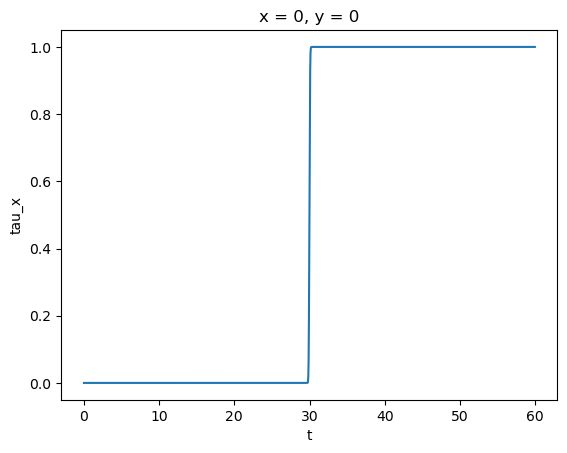

In [4]:
nt = 24 * 60
dt = 1 / 24
nx = 2
ny = 2

ds = xr.Dataset(
    coords=dict(
        x=("x", np.arange(nx)), y=("y", np.arange(ny)), t=("t", np.arange(nt) * dt)
    ),
)
# np.random()

tau_0 = 0.01
noise = 1 / 10
noise = 0
ds["tau_x"] = (("t", "x", "y"), np.random.randn(nt, nx, ny) * noise)
ds["tau_y"] = (("t", "x", "y"), np.random.randn(nt, nx, ny) * noise)
# ds["tau_x"] = ds["tau_x"] + np.heaviside(ds["t"]-ds["t"].mean("t"), .5)
ds["tau_x"] = ds["tau_x"] + (1 + erf((ds["t"] - ds["t"].mean("t")) / 0.1)) / 2

ds["tau_x"].isel(x=0, y=0).plot()

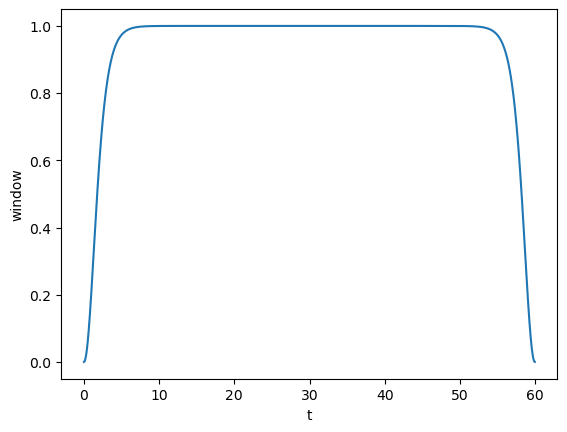

In [5]:
ds["omega"] = ("omega", fftfreq(nt, d=dt) * 2 * np.pi / 86400)  # rad/s
ds["z"] = ("z", np.arange(0, 20))

# tappering window
T_tapper = 2  # in days
ds["window"] = (
    np.tanh((ds.t - ds.t.min("t")) / T_tapper) ** 2
    * np.tanh((ds.t - ds.t.max("t")) / T_tapper) ** 2
)
ds["window"].plot()

In [6]:
s = lambda omega: np.sign(f) * np.sign(1 + omega / f)
zeta = (
    lambda z, omega: 2
    * np.sqrt(2)
    * np.exp(s(omega) * 1j * np.pi / 4)
    * z0
    / delta
    * np.sqrt((1 + z / z0) * np.abs(1 + omega / f))
)
# zeta_z = zeta(ds.z, ds.omega)
# np.abs(zeta_z).sortby("omega").plot(y="z")

In [7]:
def get_ekman_currents(omega):

    zeta_0 = zeta(0, omega)
    zeta_h = zeta(h, omega)
    zeta_z = zeta(ds.z, omega)

    G = (
        np.sqrt(2)
        * np.exp(-s(omega) * 1j * np.pi / 4)
        / rho
        / np.abs(f)
        / delta
        / np.sqrt(np.abs(1 + omega / f))
        * (iv(0, zeta_h) * kv(0, zeta_z) - iv(0, zeta_z) * kv(0, zeta_h))
        / (iv(0, zeta_h) * kv(1, zeta_0) - iv(1, zeta_0) * kv(0, zeta_h))
    )

    # !! be careful to axis of fft operation !!
    ds["tau_hat"] = (
        ("omega", "x", "y"),
        (fft((ds.tau_x + 1j * ds.tau_y) * ds.window, axis=0)),
    )

    U_hat = G * ds["tau_hat"]
    div_stress_hat = 1j * (omega + f) * U_hat

    ds["U"] = (("t", "z", "x", "y"), ifft(U_hat, axis=0))
    ds["div_stress"] = (("t", "z", "x", "y"), ifft(div_stress_hat, axis=0))

    return ds["U"], ds["div_stress"]

In [8]:
U0, div_stress0 = get_ekman_currents(ds.omega * 0.0)
U, div_stress = get_ekman_currents(ds.omega)

Text(0.5, 1.0, '')

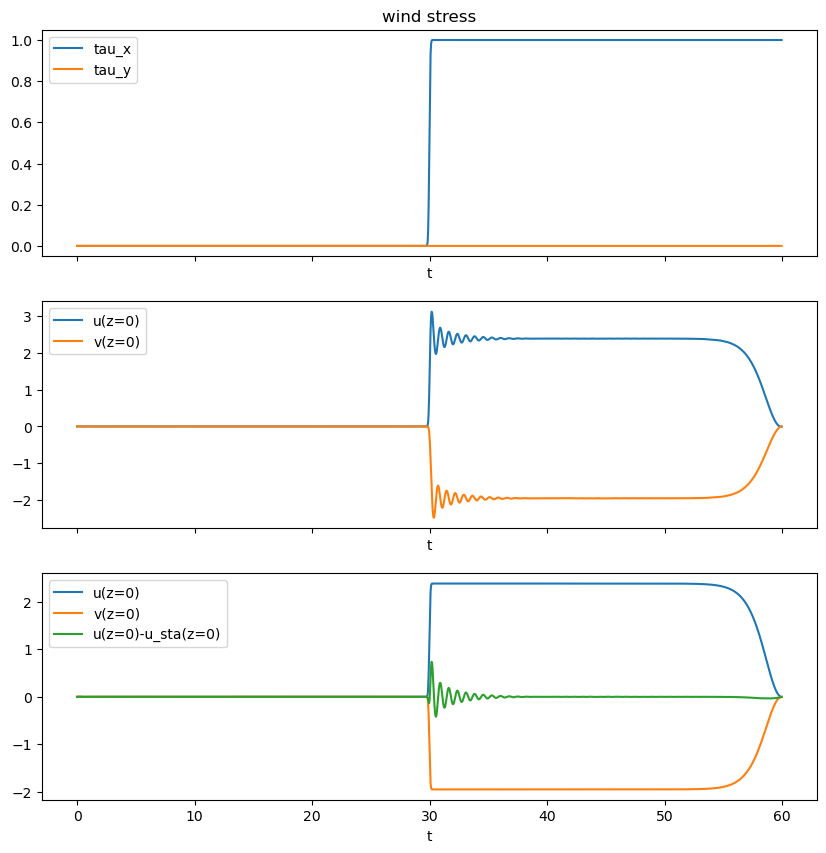

In [9]:
_ds = ds.isel(x=0, y=0)
_U0 = U0.isel(x=0, y=0)
_U = U.isel(x=0, y=0)

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 10))

ax = axes[0]
_ds["tau_x"].plot(ax=ax, label="tau_x")
_ds["tau_y"].plot(ax=ax, label="tau_y")
ax.set_ylabel("")
ax.set_title("wind stress")
ax.legend()

ax = axes[1]
_U.sel(z=0).real.plot(ax=ax, label="u(z=0)")
_U.sel(z=0).imag.plot(ax=ax, label="v(z=0)")
ax.set_ylabel("")
ax.legend()
ax.set_title("")

ax = axes[2]
_U0.sel(z=0).real.plot(ax=ax, label="u(z=0)")
_U0.sel(z=0).imag.plot(ax=ax, label="v(z=0)")
(_U.sel(z=0).real - _U0.sel(z=0).real).plot(ax=ax, label="u(z=0)-u_sta(z=0)")
ax.set_ylabel("")
ax.legend()
ax.set_title("")

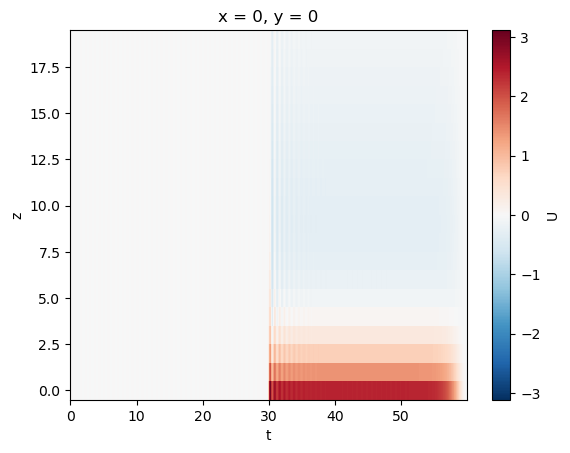

In [10]:
_ds["U"].real.plot(x="t")

---

## wrap eveything in a single callable methods

In [11]:
# helper functions
s_func = lambda omega, f: np.sign(f) * np.sign(1 + omega / f)
zeta_func = (
    lambda omega, z, delta, z0, f: 2
    * np.sqrt(2)
    * np.exp(s_func(omega, f) * 1j * np.pi / 4)
    * z0
    / delta
    * np.sqrt((1 + z / z0) * np.abs(1 + omega / f))
)


def EkmanUnified_transfer_function(
    omega,
    z,
    h,
    delta,
    z0,
    latitude,
    rho,
    verbose=False,
):
    """compute the unified Ekman transfer function
    Lilly and Elipot 2021
    """

    # derived parameters
    f = 2 * 2 * np.pi * np.sin(np.deg2rad(latitude)) / 86400
    K0 = delta**2 * f / 2
    K1 = K0 / z0
    mu = 2 * K1 / f
    if verbose:
        print(f"K0={K0:.2e} m2/s, K1={K1:.2e} m/s, mu={mu:.2e} m")

    if isinstance(omega, tuple):
        nt, dt = omega
        omega = fftfreq(nt, d=dt) * 2 * np.pi / 86400  # rad/s
    elif not isinstance(omega, np.ndarray):
        omega = np.array(omega)

    if not isinstance(z, np.ndarray):
        z = np.array(z)

    ds = xr.Dataset(
        coords=dict(
            omega=("omega", omega, dict(units="rad/s")),
            omega_cpd=("omega", omega * 86400 / 2 / np.pi, dict(units="cpd")),
            z=("z", z, dict(units="m")),
        ),
    )

    zeta_0 = zeta_func(ds.omega, 0, delta, z0, f)
    zeta_h = zeta_func(ds.omega, h, delta, z0, f)
    zeta_z = zeta_func(ds.omega, ds.z, delta, z0, f)

    ds["G"] = (
        np.sqrt(2)
        * np.exp(-s_func(ds.omega, f) * 1j * np.pi / 4)
        / rho
        / np.abs(f)
        / delta
        / np.sqrt(np.abs(1 + ds.omega / f))
        * (iv(0, zeta_h) * kv(0, zeta_z) - iv(0, zeta_z) * kv(0, zeta_h))
        / (iv(0, zeta_h) * kv(1, zeta_0) + iv(1, zeta_0) * kv(0, zeta_h))
    )

    ds.attrs.update(
        h=h,
        delta=delta,
        z0=z0,
        latitude=latitude,
        rho=rho,
        f=f,
    )

    return ds


def EkmanUnified_tseries(
    tau_x,
    tau_y,
    t,
    z,
    h,
    delta,
    z0,
    latitude,
    rho,
    T_tapper=2,  # in days
):
    """compute the current time series according the unified Ekman solution
    Lilly and Elipot 2021

    Parameters
    ----------


    """

    assert (
        tau_x.ndim == 1
    ), "code need adjustment for multidimensional dataset, ask aurelien"
    # assert taux.time.attrs["units"]=="days", ...
    ds = xr.merge([tau_x, tau_y])  # assumes xarray objects

    if not isinstance(z, np.ndarray):
        z = np.array(z)
    ds["z"] = ("z", z)

    # tappering window
    t_dim = str(t.dims[0])
    dt = float(t.diff(t_dim).mean())
    ds["window"] = (
        np.tanh((t - t.min()) / T_tapper) ** 2 * np.tanh((t - t.max()) / T_tapper) ** 2
    )

    _tau = (ds.tau_x + 1j * ds.tau_y) * ds.window
    ds["tau_hat"] = (("omega",), (fft(_tau.data, axis=_tau.get_axis_num(t_dim))))

    dsG = EkmanUnified_transfer_function(
        (t.size, dt),
        z,
        h,
        delta,
        z0,
        latitude,
        rho,
    )
    f = dsG.attrs["f"]

    # compute fourier transform variables
    U_hat = dsG.G * ds["tau_hat"]
    div_stress_hat = 1j * (dsG.omega + f) * U_hat

    # inverse fft
    ds["U"] = (
        (
            "t",
            "z",
        ),
        ifft(U_hat.data, axis=U_hat.get_axis_num("omega")),
    )
    ds["div_stress"] = (
        (
            "t",
            "z",
        ),
        ifft(div_stress_hat.data, axis=div_stress_hat.get_axis_num("omega")),
    )

    ds.attrs.update(**dsG.attrs)

    return ds

K0=1.24e-03 m2/s, K1=2.48e-04 m/s, mu=5.00e+00 m


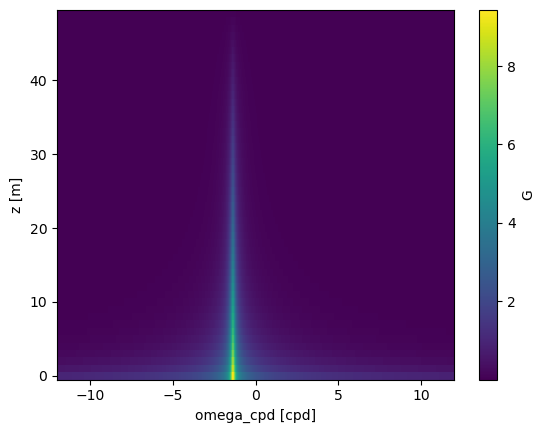

In [12]:
# input parameters
h = 50  # m
z = np.arange(0, h)
delta = 5  # m
z0 = 5  # m
latitude = 43  # deg
rho = 1025  # kg/m^3

dsG = EkmanUnified_transfer_function(
    (24 * 100, 1 / 24),
    z,
    h,
    delta,
    z0,
    latitude,
    rho,
    verbose=True,
)

np.abs(dsG.G).sortby("omega").plot(x="omega_cpd")

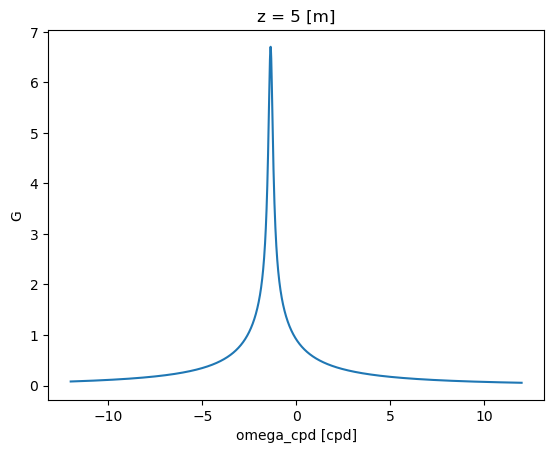

In [9]:
_G = np.abs(dsG.G).sortby("omega").sel(z=5, method="nearest")

_G.plot(x="omega_cpd")

In [10]:
# assemble test dataset
nt, dt = 24 * 60, 1 / 24
ds = xr.Dataset(
    coords=dict(time=("time", np.arange(nt) * dt)),
)

tau_0 = 0.01
# noise = tau_0/10
noise = 0
ds["tau_x"] = (("time",), np.random.randn(nt) * noise)
ds["tau_y"] = (("time",), np.random.randn(nt) * noise)
# ds["tau_x"] = ds["tau_x"] + np.heaviside(ds["t"]-ds["t"].mean("t"), .5)
ds["tau_x"] = (
    ds["tau_x"] + tau_0 * (1 + erf((ds["time"] - ds["time"].mean("time")) / 0.1)) / 2
)

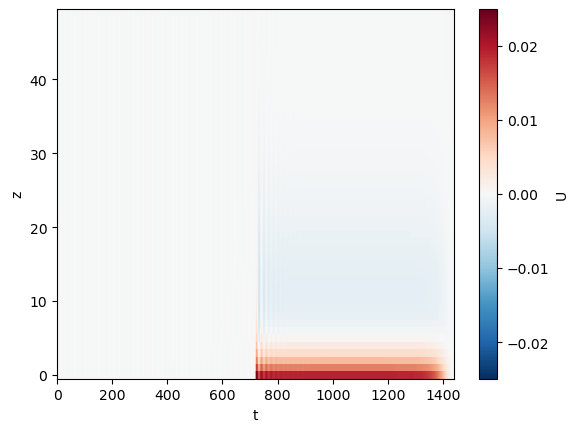

In [11]:
ds = EkmanUnified_tseries(
    ds.tau_x,
    ds.tau_y,
    ds.time,
    z,
    h,
    delta,
    z0,
    latitude,
    rho,
    T_tapper=2,  # in days
)

ds["U"].real.plot(x="t")

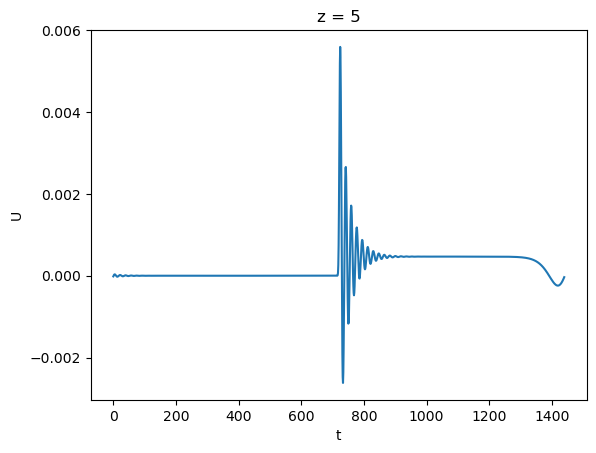

In [12]:
ds["U"].sel(z=5, method="nearest").real.plot(x="t")